# Qiskit Statevector Benchmark for Kagome Lattice Dynamics

In the following an exact reference simulation (up to Trotter error) is implemented of the same Kagome lattice transverse-field Ising model studied in 'kagome.ipynb'.\
While the SPD method is an approximation, here an exact method is implemented using the Qiskit Aer statevector simulator for reference purposes.[1]

In [ ]:
try:
    from spd.SparsePauliDynamics import *
    from spd.BaseOperatorRepresentation import * 
except ImportError:
    print("\n" + "="*60)
    print("REQUIRED PACKAGE 'spd' NOT FOUND")
    print("="*60)
    print("This notebook relies on the 'spd' package.")
    print("Please install it before proceeding:\n")
    print("   pip install git+https://github.com/tbegusic/spd.git")
    print("="*60 + "\n")
    raise
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.hamiltonians.lattices import (
    KagomeLattice,
    BoundaryCondition,
)
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from qiskit_aer import AerSimulator


In [ ]:
Lx, Ly = 3, 2
kagome = KagomeLattice(rows=Lx, cols=Ly,
    boundary_condition=(BoundaryCondition.PERIODIC, BoundaryCondition.PERIODIC)
)
nq = kagome.num_nodes
weighted_edges = kagome.weighted_edge_list
nlist = [(i, j) for i, j, _ in weighted_edges if i != j]

In [ ]:
hc = 1
h = hc
hzz = SparsePauliOp.from_sparse_list([("ZZ", pair, 1.0) for pair in nlist], num_qubits=nq)
hx = SparsePauliOp.from_sparse_list([("X", [i], h) for i in range(nq)], num_qubits=nq)
h_tot = hzz + hx
obs = SparsePauliOp.from_sparse_list([("Z", [(nq-1)//2], 1.0)], num_qubits=nq)
(nq-1)//2

In [ ]:
t = 1
dt = 0.02
nsteps = int(t/dt)

To implement the exact simulation, first a quantum circuit is built containing $nsteps$ identical Trotter steps. \
The $\texttt{PauliEvolutionGate}$ then does the first order Trotterization as $e^{-iH\Delta t} \approx \prod_j e^{-i c_j \Delta t H_j}$.\
Saving the statevector after each time step, allows computing the observable at all intermediate times without having to re-run the simulation.

In [ ]:
qc = QuantumCircuit(nq)

# Save the initial state (t=0)
qc.save_statevector(label='psi_0')

for step in range(nsteps):
    # Append time evolution for one step dt
    evo = PauliEvolutionGate(h_tot, time=dt, synthesis=LieTrotter())
    qc.append(evo, range(nq))
    # Save the state after this step
    qc.save_statevector(label=f'psi_{step+1}')

The simulation is run by making use of the $\texttt{AerSimulator}$, which performs an exact evolution of the full statevector.

In [ ]:
sim = AerSimulator(method='statevector')
qc_compiled = transpile(qc, sim)
result = sim.run(qc_compiled).result()
data = result.data(0)

The expectation values are then computed for each saved statevector and then saved in a list.

In [ ]:
# Extract expectation values
times = np.arange(nsteps + 1) * dt
exp_vals = []
for step in range(nsteps + 1):
    sv = Statevector(data[f'psi_{step}'])
    exp_val = sv.expectation_value(obs).real
    exp_vals.append(exp_val)

In [ ]:
plt.plot(times, exp_vals)
plt.show()

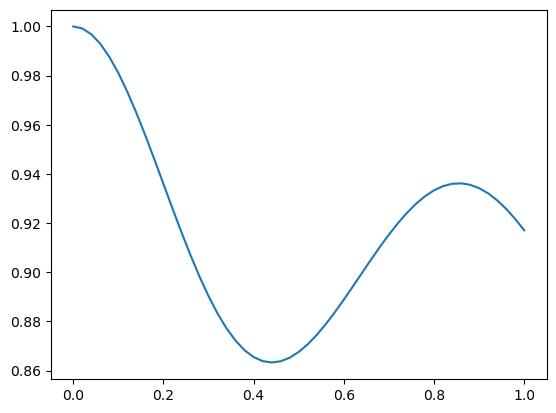

## References

[1] “AerSimulator - Qiskit Aer 0.17.1.” Accessed April 21, 2026. https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html.
